In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.ndimage import gaussian_filter
import pandas as pd
from tqdm.notebook import trange, tqdm

In [2]:
#Fase caricamento dati in x e y
hdulist = fits.open('data_cubet.fits')
#estraggo data_cube
datcube = hdulist[0].data #immagini
X = datcube[:, 2, :, :] #mappa dispersione
dataset = pd.read_excel('dataset.xlsx') #etichette
y=dataset.Vdisp
hdulist.close()
print(y)
X.shape
nan_indices = np.isnan(X)
X[nan_indices] = -999

0       135.284239
1       199.274402
2        57.341607
3        74.534807
4        84.774836
           ...    
9995     45.770637
9996    165.280073
9997    246.502903
9998    161.662235
9999    135.280471
Name: Vdisp, Length: 10000, dtype: float64


In [3]:
#Fase suddivisione dati
from sklearn.model_selection import train_test_split

#X_max=np.nanmax(np.abs(X), axis=(1,2))
#X_norm= X/X_max[:,None,None]
#y_norm= y/X_max

X_max=1
X_norm= X/X_max
y_norm= y/X_max

#uso la funzione train_test_split per suddividere i dati in un set di addestramento (training set 70%) e un set di test (test set 30%)
X_train, X_split, y_train, y_split = train_test_split(X_norm, y_norm, test_size=0.3, random_state=42, shuffle=True) #random_state per la riproducibilità, e shuffle per mescolamento dati
#suddivido set di test in validazione (66,6%) e test (33,3%)
X_valid, X_test, y_valid, y_test = train_test_split(X_split, y_split, test_size=0.666, random_state=42, shuffle=True)


In [4]:
#ridimensiono sia array di X test che valid che addestr in un formato che rappresenta le immagini in array tridimensionali
imsize = np.shape(X_train)[2]
X_train = X_train.reshape(-1, imsize, imsize, 1) #-1 cioè tutte le immagini, 3 cioè i canali (le 3 mappe) 
X_valid = X_valid.reshape(-1, imsize, imsize, 1)
X_test = X_test.reshape(-1, imsize, imsize, 1)
X_test.shape
print(X_test.shape)
X_train.shape
print(X_train.shape)
X_valid.shape
print(X_valid.shape)

(1998, 81, 81, 1)
(7000, 81, 81, 1)
(1002, 81, 81, 1)


In [5]:
import tensorflow.compat.v1 as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, BatchNormalization
from keras.layers import Conv2D, MaxPooling2D
from keras.utils import to_categorical
from keras.preprocessing import image

def Model_gal2(input_shape=(imsize,imsize, 1), learning_rate=0.001):
    model = Sequential()
    model.add(Conv2D(16, kernel_size=(3,3),activation='relu', input_shape=input_shape,  name='conv1')) #strato conv con 32 nodi di output, prende immagini in input e inizia elaborazione
    #model.add(Conv2D(32, (3, 3), activation='relu', name='conv2'))
    model.add(MaxPooling2D(pool_size=(2, 2))) #riduce dimensioni spaziali dell'output precedente, estrae caratteristiche piu' importanti tramite il max nell'area in cui è applicato il filtro
    #model.add(Dropout(0.25)) # probabilità del 25% di azzerare connessioni durante addestramento (previene overfitting)

    model.add(Conv2D(32, (3, 3), activation='relu', name='conv3'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu', name='conv4'))
   # model.add(BatchNormalization(axis = 3, name = 'bn')) #l'asse=3 specifica l'asse lungo il quale viene applicata la normalizzazione (per migliorare stabilità dell'addestramento), nel nostro caso al canale(che è 3) e quindi la normalizzazione è applicata a ciascuna mappa separatamente
    model.add(MaxPooling2D(pool_size=(2, 2)))
    #model.add(Dropout(0.25))#aumento prob a 50%

    model.add(Flatten()) #trasfroma output precedente da 2D a 1D
    model.add(Dense(128, activation='relu', name='den1'))
    #model.add(Dense(32, activation='relu', name='den2'))
    #model.add(Dense(8, activation='relu', name='den3'))

    model.add(Dense(1, activation='linear', name='fc_out'))# genera l'output finale, che rappresenta la previsione numerica , NB non so quale funzione di attivazione usare
    model.summary()
    #Fase compilazione
    model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate), metrics=['mse', 'mae']) #adam attua automaticamente il tasso di apprensimento durante l'addestramento
#si usa mse per prevedere un valore numerico anziché classificare in categorie, misura la media dei quadrati delle differenze tra le previsioni del modello e i valori di target reali.
#mae calcola la media delle differenze assolute tra le previsioni del modello e i valori di target reali
    return model

In [6]:
model = Model_gal2()

C:\Users\39351\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape              ┃    Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 79, 79, 16)        │        160 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 39, 39, 16)        │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ conv3 (Conv2D)                  │ (None, 37, 37, 32)        │      4,640 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 18, 18, 32)        │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 64)        │     18,496 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)          │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ flatten (Flatten)               │ (None, 4096)              │          0 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ den1 (Dense)                    │ (None, 128)               │    524,416 │
├─────────────────────────────────┼───────────────────────────┼────────────┤
│ fc_out (Dense)                  │ (None, 1)                 │        129 │
└─────────────────────────────────┴───────────────────────────┴────────────┘

 Total params: 547,841 (2.09 MB)

 Trainable params: 547,841 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history=model.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=20,batch_size=128)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 24s 283ms/step - loss: 75332.7344 - mae: 154.0253 - mse: 75337.6641 - val_loss: 380.3038 - val_mae: 14.0352 - val_mse: 379.4435
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 14s 246ms/step - loss: 317.4196 - mae: 12.1975 - mse: 317.4387 - val_loss: 150.8312 - val_mae: 9.2230 - val_mse: 150.3406
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 14s 260ms/step - loss: 174.9790 - mae: 9.1690 - mse: 174.9804 - val_loss: 120.2846 - val_mae: 7.9184 - val_mse: 119.7720
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 21s 266ms/step - loss: 117.2086 - mae: 7.6870 - mse: 117.2093 - val_loss: 109.2274 - val_mae: 7.8180 - val_mse: 108.7449
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 15s 264ms/step - loss: 113.6440 - mae: 7.7275 - mse: 113.6469 - val_loss: 97.0444 - val_mae: 6.9982 - val_mse: 96.4288
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 21s 267ms/step - loss: 91.2628 - mae: 6.8145 - mse: 91.2671 - val_loss: 90.1014 - val_mae: 6.7083 - val_mse: 89.6769
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 14s 25

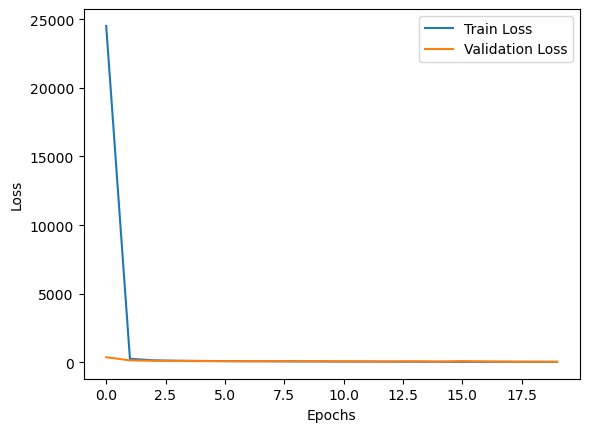

In [8]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
y_test_pred=model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step


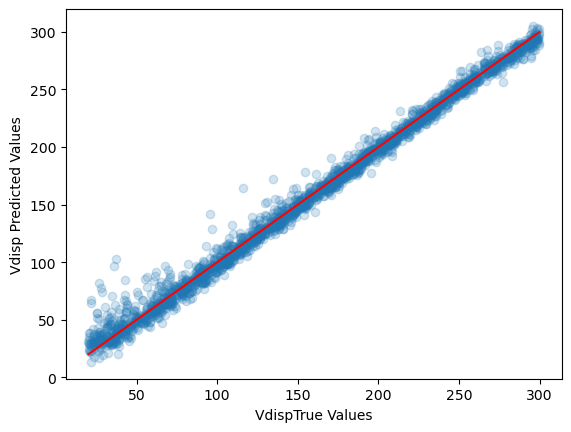

In [10]:
plt.scatter(y_test, y_test_pred, label='Test Data',alpha=0.2)
plt.xlabel('VdispTrue Values')
plt.ylabel('Vdisp Predicted Values')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()], color='red')

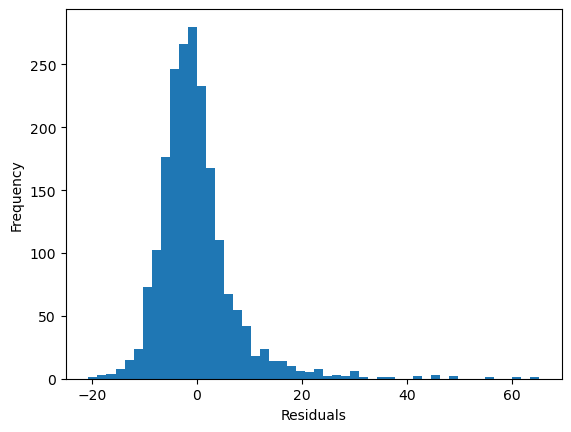

In [11]:
#calcolo residui
y_test_pred = y_test_pred.ravel()
residuals = y_test_pred - y_test
plt.hist(residuals, bins=50)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

In [12]:
#calcolo deviazione standard  dei residui con RMSE
std_deviation = np.std(residuals)
rmse = np.sqrt(np.mean(residuals**2))
print('std_deviation:',std_deviation)
print('rmse:',rmse)


std_deviation: 7.5081249747732
rmse: 7.512994428776506


In [33]:
file_path = r"C:\Users\39351\Downloads\maps\UGC731\UGC731map_2nd.fits"

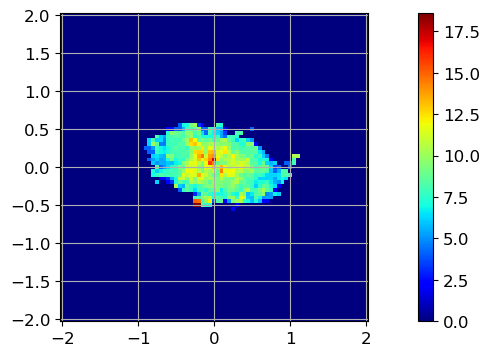

In [14]:
hdulist = fits.open(file_path)
X_vera = hdulist[0].data
nan_indices = np.isnan(X_vera)
X_vera[nan_indices] = 0
plt.rcParams['figure.figsize'] = [16, 4]
plt.rcParams['figure.dpi']= 100 # set plot image resolution (dpi)
plt.rcParams.update({'font.size': 12})

fig, ax1 = plt.subplots(1)
def vmin(array):
    return np.abs(np.nanpercentile(array, 5))
def vmax(array):
    return np.nanpercentile(array, 95)
extent = [-2.025, 2.025, -2.025, 2.025]
#plt.imshow(hdu_data, origin='lower', cmap='jet')
cset1 = ax1.imshow(X_vera, origin='lower',  extent=extent, cmap='jet') #vmin=vmin(map_flux), vmax=vmax(map_flux), cmap='jet')
ax1.grid()
fig.colorbar(cset1, fraction=0.046, pad=0.04, ax=ax1)
plt.show()

In [15]:
# Aggiungi una dimensione per il batch
X_vera_1= np.expand_dims(X_vera, axis=0)

# Aggiungi una dimensione per il canale
X_vera_final = np.expand_dims(X_vera_1, axis=-1)
print(X_vera_final.shape)
y_test_pred1=model.predict(X_vera_final)

(1, 81, 81, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [16]:
print(y_test_pred1)

[[1.9898723]]


In [17]:
file_path = r"C:\Users\39351\Downloads\maps\ALESS73.1\ALESS73.1map_2nd.fits"

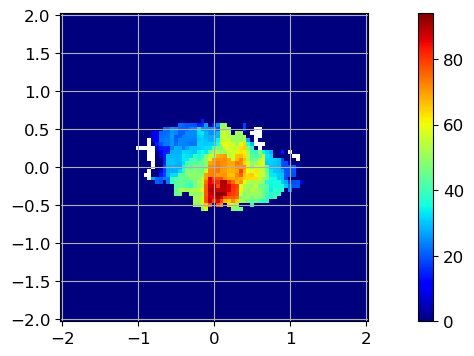

In [18]:
hdulist = fits.open(file_path)
X_vera2 = hdulist[0].data
X_vera2[nan_indices] = 0
nan_indices = np.isnan(X_vera2)
plt.rcParams['figure.figsize'] = [16, 4]
plt.rcParams['figure.dpi']= 100 # set plot image resolution (dpi)
plt.rcParams.update({'font.size': 12})

fig, ax1 = plt.subplots(1)
def vmin(array):
    return np.abs(np.nanpercentile(array, 5))
def vmax(array):
    return np.nanpercentile(array, 95)
extent = [-2.025, 2.025, -2.025, 2.025]
#plt.imshow(hdu_data, origin='lower', cmap='jet')
cset1 = ax1.imshow(X_vera2, origin='lower',  extent=extent, cmap='jet') #vmin=vmin(map_flux), vmax=vmax(map_flux), cmap='jet')
ax1.grid()
fig.colorbar(cset1, fraction=0.046, pad=0.04, ax=ax1)
plt.show()

In [19]:
# Aggiungi una dimensione per il batch
X_vera_2= np.expand_dims(X_vera2, axis=0)

# Aggiungi una dimensione per il canale
X_vera_final2 = np.expand_dims(X_vera_2, axis=-1)
print(X_vera_final.shape)
y_test_pred2=model.predict(X_vera_final2)

(1, 81, 81, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [20]:
print(y_test_pred2)

[[12.62921]]
